In [1]:
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Layer
from tensorflow.keras.initializers import RandomUniform, Constant
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import RMSprop, SGD

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

2025-10-09 16:50:38.480766: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-09 16:50:38.542082: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-10-09 16:50:38.542111: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-09 16:50:38.543417: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-10-09 16:50:38.551016: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-09 16:50:38.551751: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [2]:
!pip install tf-levenberg-marquardt 

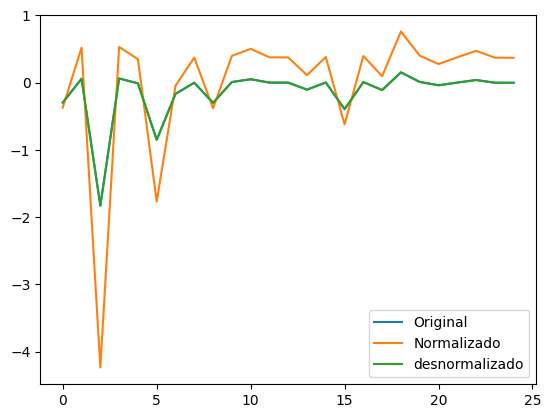

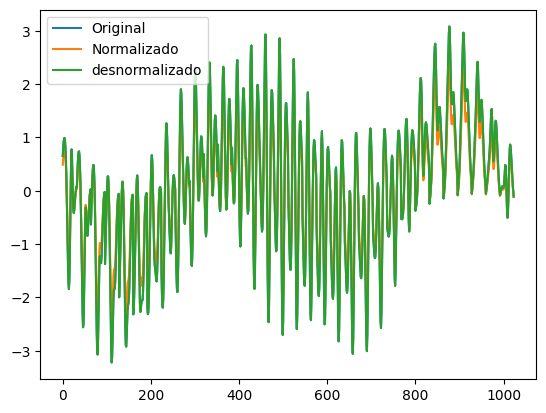

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def create_dataframe_(filepath, grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    df = pd.read_excel(filepath)
    z_pred_25 = df['Z_pred'].values.reshape(-1, 1)
    z_25= z.flatten().reshape(-1, 1) - z_pred_25
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_25.flatten()}
    df = pd.DataFrame(data)
    return df

def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()


df_25 = create_dataframe_(f"25_model_12_6_0.xlsx", grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(f"1000_model_12_6_0.xlsx",grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [4]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [ ]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm
from tensorflow.keras.layers import Layer, Dense
from tensorflow.keras.initializers import Initializer, Constant, RandomUniform
from sklearn.cluster import KMeans
import keras.backend as K  # ou tf.keras.backend as K

# Initializer for initialization of centers of RBF networ
class InitCentersKMeans(Initializer):
    def __init__(self, X, max_iter=100):
        self.X = X
        self.max_iter = max_iter
# X: matrix, dataset to choose the centers from 
    def __call__(self, shape, dtype=None):
        assert shape[1] == self.X.shape[1]
        idx = np.random.randint(self.X.shape[0], size=shape[0])
        return self.X[idx, :]
    
    
# Classe RBFLayer
class RBFLayer(Layer):
    def __init__(self, output_dim, initializer=None, betas=1.0, **kwargs):
        self.output_dim = output_dim
        self.init_betas = betas
        if not initializer:
            self.initializer = RandomUniform(0.0, 1.0)
        else:
            self.initializer = initializer
        super(RBFLayer, self).__init__(**kwargs)


    def build(self, input_shape):
        self.centers = self.add_weight(
            name='centers',
            shape=(self.output_dim, input_shape[-1]),
            initializer=self.initializer,
            trainable=True
        )
        self.betas = self.add_weight(
            name='betas',
            shape=(self.output_dim,),
            initializer=Constant(value=self.init_betas),
            trainable=True
        )
        super(RBFLayer, self).build(input_shape)

    def call(self, x):
        C = tf.expand_dims(self.centers, axis=0)
        X = tf.expand_dims(x, axis=1)
        diff = X - C
        return tf.exp(-self.betas * tf.reduce_sum(diff**2, axis=-1))
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.output_dim)

    def get_config(self):
        # have to define get_config to be able to use model_from_json
        config = {
            'output_dim': self.output_dim
        }
        base_config = super(RBFLayer, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))



# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))
        self.model = None  # o modelo será criado em set_architecture()
   
    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
        
    def set_architecture(self, X_train):
        """Define arquitetura RBF: uma camada radial + saída densa."""
        self.model = Sequential()
        # Camada RBF oculta
        self.model.add(
            RBFLayer(
                self.hidden_sizes[0],               # número de funções radiais
                initializer=InitCentersKMeans(X_train),
                betas=1.0,                          # fator de espalhamento (ajustável)
                input_shape=(self.input_size,)
            )
        )

        # Camada de saída (linear)
        self.model.add(Dense(
            self.output_size,
            activation=None,                       # sem ativação na Dense
            kernel_regularizer=self.regularizer
        ))
        self.model.add(Activation('linear'))

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


In [6]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [7]:
import tensorflow as tf 
import numpy as np 
from keras import regularizers 
from keras import initializers 
import tf_levenberg_marquardt as lm 
from tensorflow.keras.layers import Layer, Dense 
from tensorflow.keras.initializers import Initializer, Constant, RandomUniform 
from sklearn.cluster import KMeans 
import keras.backend as K # ou tf.keras.backend as K
from itertools import product
import pickle

class TesterRBF:
    def __init__(self, run_times=25, dataset_run_times=10):
        self.run_times = run_times
        self.dataset_run_times = dataset_run_times
        self.better_metrics = {}
        # Dados já normalizados
        self.input_25, self.output_25 = split_df(df_25_norm)
        self.input_1000, self.output_1000 = split_df(df_1000_norm)

    def setArchitecure(self, trainer, hidden_size, reg,_lr):
        # Inicializa Sequential
        trainer.model = tf.keras.models.Sequential()
        
        # Usa X_train para inicializar centros RBF
        X_train = trainer.train_input.numpy().reshape(-1, 2)
        
        shuffler = ShuffleArchitecture(
            input_size=2,
            hidden_sizes=hidden_size,
            output_size=1,
            param_reg=reg
        )
        shuffler.model = trainer.model
        shuffler.set_architecture(X_train)
        
        # Cria modelo Levenberg-Marquardt
        trainer.lm_model = shuffler.create_model(_lr)
        trainer.k = shuffler.compute_k()

    def Train(self, trainer, epochs=1000):
        trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
        return trainer.get_metrics(), trainer.lm_model

    def SaveModelWeights(self, model, fileName):
        path = f"content/models/{fileName}.keras"
        open(path,'w').close()
        model.save_weights(path)

    def SaveDataset(self, trainer, fileName):
        path = f"content/dataset/{fileName}.pkl" 
        with open(path, 'wb') as f:
            pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)

    def LoopWeights(self, sort_by, boundarie, trainer, idx):
        better_model = 0
        save = False

        for i in range(self.run_times):
            print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
            metrics, model = self.Train(trainer)
            if (metrics[sort_by] <= boundarie): # should be >= to acsending metrics
                fileName = f"model_{idx}_{better_model}"
                self.SaveModelWeights(model, fileName)
                self.better_metrics[fileName] = metrics
                better_model += 1
                save = True
            return(save)

    def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
        trainer = TrainWithSmallDataset()

        for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
            header = f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
            print(f"Testando combinação {count}: {header}")

            for j in range(self.dataset_run_times):
                # 🔹 PRIMEIRO: cria os conjuntos de treino/val/test
                trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
                
                # 🔹 DEPOIS: usa X_train para definir os centros RBF
                self.setArchitecure(trainer, hidden_size, reg,lr)

                # 🔹 Executa o treino e verificação dos melhores resultados
                if self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}"):
                    self.SaveDataset(trainer, f"dataset_{count}_{j}")
                    self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
                
                self.better_metrics = {}
    def DisplayBetterResults(self, sort_by, header, dataset=0):
        df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
        df = df.sort_values([sort_by])
        display(df)
        path = f'content/results/metrics_{dataset}'
        df.to_excel(f"{path}.xlsx", index=True)
        print(f"DataFrame salvo em {path}")
        with open(f"{path}.txt", 'w') as arquivo:
            arquivo.write(header)


# Treinando com 25 dados


In [8]:
tester = TesterRBF(run_times=25, dataset_run_times=10)
tester.Loop(
    sort_by='r2',
    boundarie=0.8,
    hidden_sizes=[[15], [16], [17], [18], [19],[20], [21], [22], [23],[24],[25] ],
    regularizers=[0.2, 0.05],
    learning_rate=[0.01, 0.1]
)

Testando combinação 1: Hidden Size=[15], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step


,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_0_0,0.022444,-0.096515,-1.944203,-0.171232,-0.639255,1.600757,1.795553,0.265607,0.233127,0.249367,1.226405,1.26521,1.634091,1.319073,121.059046,195.410472


DataFrame salvo em content/results/metrics_1_0
+++++++++++ [1_1] | 1 ++++++++++++++++++


Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step


,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_1_1_0,-0.241465,-0.115406,-0.221339,-9.214742,-0.102808,2.03291,1.826487,7.512225,0.421175,3.9667,1.937298,1.425801,1.805274,1.486501,120.581064,194.932489


...

DataFrame salvo em content/results/metrics_44_7
+++++++++++ [44_8] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step


,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_44_8_0,0.008856,-0.095554,-127.056253,0.02049,-0.029906,1.623007,1.79398,0.343183,1.38055,0.861867,1.196888,1.273973,1.308928,1.328209,201.031439,324.137897


DataFrame salvo em content/results/metrics_44_8
+++++++++++ [44_9] | 1 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 3ms/step


,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_44_9_0,0.028247,0.060545,0.014515,0.468243,0.232586,1.591254,1.538366,0.265964,0.099949,0.182957,1.33218,1.261449,1.302884,1.315152,201.070955,324.177413


DataFrame salvo em content/results/metrics_44_9
